### MOMM PROJECT


## 🌐 **Google Drive Connection**

In [1]:
# from google.colab import drive
# drive.mount("/gdrive")
# current_dir = "/gdrive/My\\ Drive//MolModMaterialsProject/MMOM-project"
# %cd $current_dir

## ⚙️ **Libraries Import**

In [2]:
# !pip install numba-progress
# !pip install torchsummary
# !pip install tensorboard
# !pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import random
import numpy as np
from datetime import datetime

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(SEED)
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from numba import njit, prange
from tqdm.auto import tqdm
from scipy.fftpack import fft, fftfreq

logs_dir = "networks"

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from lammps import lammps
from extract_dump import parse_lammps_dump_to_csv
import glob

rng = np.random.default_rng(SEED)

PyTorch version: 2.12.1
Device: mps


## 🐱 **Hyperparameters**

In [3]:
BATCH_SIZE = 128

# Model architecture configuration
HIDDEN_LAYERS = 2
HIDDEN_SIZE   = 64
DROPOUT_RATE = 0.0

LEARNING_RATE = 1e-4
EPOCHS = 1500
PATIENCE = 75
L2_LAMBDA = 0.0


N_RADIAL = 32
N_ANGULAR = 16

## ⏳ **Data Loading**

In [4]:
os.makedirs("Si_dataset", exist_ok=True)

In [5]:
# ============================================================
# Common LAMMPS initialization
# ============================================================

def setup_lammps():
    # Force Python to find the correct DLLs in the LAMMPS installation folder
    lammps_bin = r"C:\Users\giorg\AppData\Local\LAMMPS 64-bit 22Jul2025-MSMPI with Python\bin"
    
    if os.path.exists(lammps_bin):
        os.add_dll_directory(lammps_bin)
    
    lmp = lammps()

    cmds = """

    units metal
    dimension 3
    boundary p p p
    atom_style atomic


    lattice diamond 5.431

    region box block 0 2 0 2 0 2

    create_box 1 box
    create_atoms 1 box


    mass 1 28.0855


    pair_style sw
    pair_coeff * * Si.sw Si


    timestep 0.001


    compute eatom all pe/atom


    thermo 1000
    thermo_style custom step temp pe etotal press


    """

    lmp.commands_string(cmds)

    return lmp



# ============================================================
# Save dataset snapshot
# ============================================================

def setup_dump(lmp, filename):

    lmp.commands_string(f"""

    dump d1 all custom 1000 Si_dataset/{filename} \
    id type x y z fx fy fz c_eatom

    dump_modify d1 sort id

    """)


# ============================================================
# 1) Perfect crystal at 300K
# ============================================================

def crystal():

    if os.path.exists("Si_dataset/crystal.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"crystal.dump")


    lmp.commands_string("""
    
    velocity all create 300 12345

    fix 1 all nvt temp 300 300 0.1

    run 200000

    unfix 1

    """)

    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/crystal.dump", "Si_dataset/crystal.csv")



# ============================================================
# 2) Strained crystal
# ============================================================

def strained():

    if os.path.exists("Si_dataset/strained.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"strained.dump")


    lmp.commands_string("""
    
    change_box all x scale 1.05 \
                    y scale 1.05 \
                    z scale 1.05 remap


    velocity all create 500 22222

    fix 1 all nvt temp 500 500 0.1

    run 200000

    unfix 1

    """)

    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/strained.dump", "Si_dataset/strained.csv")

# ============================================================
# 3) Hot solid
# ============================================================

def hot():
    if os.path.exists("Si_dataset/hot.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"hot.dump")


    lmp.commands_string("""
    
    velocity all create 1500 33333


    fix 1 all nvt temp 1500 1500 0.1


    run 200000


    unfix 1

    """)


    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/hot.dump", "Si_dataset/hot.csv")


# ============================================================
# 4) Liquid silicon
# ============================================================

def liquid():
    if os.path.exists("Si_dataset/liquid.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"liquid.dump")


    lmp.commands_string("""
    
    velocity all create 3000 44444


    fix 1 all nvt temp 3000 3000 0.1


    run 300000


    unfix 1

    """)


    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/liquid.dump", "Si_dataset/liquid.csv")


# ============================================================
# 5) Amorphous silicon
# ============================================================

def amorphous():
    if os.path.exists("Si_dataset/amorphous.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"amorphous.dump")


    lmp.commands_string("""
    
    velocity all create 3000 55555


    fix 1 all nvt temp 3000 300 0.1


    run 300000


    unfix 1


    velocity all create 300 77777


    fix 2 all nvt temp 300 300 0.1


    run 100000


    unfix 2

    """)


    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/amorphous.dump", "Si_dataset/amorphous.csv")



# ============================================================
# RUN ALL DATA GENERATION
# ============================================================

print("Generating crystal...")
crystal()

print("Generating strained...")
strained()

print("Generating hot...")
hot()

print("Generating liquid...")
liquid()

print("Generating amorphous...")
amorphous()


print("Dataset generation completed")

Generating crystal...
Generating strained...
Generating hot...
Generating liquid...
Generating amorphous...
Dataset generation completed


In [6]:
import os
import glob
import pandas as pd

def parse_lammps_dump_to_csv(filepath, output_csv):
    print(f"Extracting {filepath} to {output_csv}...")
    with open(output_csv, 'w') as out_f:
        header = "timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,fz,pe_atom\n"
        out_f.write(header)
        with open(filepath, 'r') as f:
            while True:
                line = f.readline()
                if not line:
                    break
                if "ITEM: TIMESTEP" in line:
                    timestep = f.readline().strip()
                elif "ITEM: NUMBER OF ATOMS" in line:
                    n_atoms = int(f.readline().strip())
                elif "ITEM: BOX BOUNDS" in line:
                    box_x_data = f.readline().split()
                    box_y_data = f.readline().split()
                    box_z_data = f.readline().split()
                    box_x = f"{float(box_x_data[1]) - float(box_x_data[0]):.4f}"
                    box_y = f"{float(box_y_data[1]) - float(box_y_data[0]):.4f}"
                    box_z = f"{float(box_z_data[1]) - float(box_z_data[0]):.4f}"
                elif "ITEM: ATOMS" in line:
                    for _ in range(n_atoms):
                        data = f.readline().split()
                        atom_id = data[0]
                        x, y, z = data[2], data[3], data[4]
                        fx, fy, fz = data[5], data[6], data[7]
                        pe_atom = data[8]
                        row = f"{timestep},{box_x},{box_y},{box_z},{atom_id},{x},{y},{z},{fx},{fy},{fz},{pe_atom}\n"
                        out_f.write(row)
    print("Done")

dump_files = glob.glob("Si_dataset/*.dump")
for dump_file in dump_files:
    csv_file = dump_file.replace(".dump", ".csv")
    if not os.path.exists(csv_file):
        parse_lammps_dump_to_csv(dump_file, csv_file)

if os.path.exists("Si_dataset/unified_dataset.csv"):
    print("Unified dataset already exists. Skipping concatenation.")
else:
    csv_files = glob.glob("Si_dataset/*.csv")
    if not csv_files:
        print("Error: No CSV files found.")
    else:
        dfs = [pd.read_csv(file) for file in csv_files]
        data = pd.concat(dfs, ignore_index=True)
        data.to_csv("Si_dataset/unified_dataset.csv", index=False)
        print(f"Unified {len(csv_files)} CSV files into Si_dataset/unified_dataset.csv")
        print(f"Combined dataset shape: {data.shape}")

Unified dataset already exists. Skipping concatenation.


In [7]:
if os.path.exists("Si_dataset/unified_dataset.csv"):
    print("Unified dataset already exists. Skipping concatenation.")
else:
    # Get all CSV files from the Si_dataset directory
    csv_files = glob.glob("Si_dataset/*.csv")

    # Read and concatenate all CSV files
    dfs = [pd.read_csv(file) for file in csv_files]
    data = pd.concat(dfs, ignore_index=True)

    # Save the unified dataset
    data.to_csv("Si_dataset/unified_dataset.csv", index=False)

    print(f"Unified {len(csv_files)} CSV files into Si_dataset/unified_dataset.csv")
    print(f"Combined dataset shape: {data.shape}")
    print(f"Files merged: {csv_files}")

Unified dataset already exists. Skipping concatenation.


In [8]:
symmetry_dataset_path = f'lammps/silicon_symmetry_dataset_64_forces.csv'
extracted_data_path = 'lammps/dataset64.csv'
if not os.path.exists(extracted_data_path):
    try:
        # try to find the correspective .dump file and extract it to .csv
        parse_lammps_dump_to_csv(extracted_data_path[:-4] + '.dump', extracted_data_path)
    except Exception as e:
        print(f"Error occurred while parsing LAMMPS dump file: {e}")

generate = True

# Set file_path based on existence of the symmetry dataset
if os.path.exists(symmetry_dataset_path):
    file_path = symmetry_dataset_path
    generate = False
    print(f"Using augmented dataset: {file_path}")
else:
    file_path = extracted_data_path
    print(f"Augmented dataset not found. Using original data: {file_path}")

data = pd.read_csv(file_path, engine='pyarrow')
# lower = 8000
# upper = 9001
# data = data[(data['timestep'] <= upper) & (data['timestep'] >= lower)].reset_index(drop=True)
# Display the first few rows of the data
display(data.head())

Using augmented dataset: lammps/silicon_symmetry_dataset_64_forces.csv


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,...,g2_30,g2_31,g2_32,g2_33,g2_34,g2_35,g2_36,g2_37,g2_38,g2_39
0,0,10.862,10.862,10.862,1,0.00000,0.00000,0.00000,4.235760e-15,4.235740e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,10.862,10.862,10.862,2,2.71550,2.71550,0.00000,-4.790280e-16,-4.790280e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,10.862,10.862,10.862,3,1.35775,1.35775,1.35775,-2.710510e-20,-2.710510e-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,10.862,10.862,10.862,4,4.07325,4.07325,1.35775,3.174820e-15,3.174810e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,10.862,10.862,10.862,5,0.00000,2.71550,2.71550,7.345740e-15,-4.311600e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 🔎 **Exploration and Data Analysis**

In [9]:
# Assign the loaded data to silicon_dataset
silicon_dataset = data
print('Silicon dataset shape:', silicon_dataset.shape)

# Display the first 10 rows of the dataset
silicon_dataset.head(10)

Silicon dataset shape: (576064, 84)


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,...,g2_30,g2_31,g2_32,g2_33,g2_34,g2_35,g2_36,g2_37,g2_38,g2_39
0,0,10.862,10.862,10.862,1,0.00000,0.00000,0.00000,4.235760e-15,4.235740e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,10.862,10.862,10.862,2,2.71550,2.71550,0.00000,-4.790280e-16,-4.790280e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,10.862,10.862,10.862,3,1.35775,1.35775,1.35775,-2.710510e-20,-2.710510e-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,10.862,10.862,10.862,4,4.07325,4.07325,1.35775,3.174820e-15,3.174810e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,10.862,10.862,10.862,5,0.00000,2.71550,2.71550,7.345740e-15,-4.311600e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,10.862,10.862,10.862,6,2.71550,0.00000,2.71550,-4.311600e-16,7.345710e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,10.862,10.862,10.862,7,1.35775,4.07325,4.07325,-2.144930e-15,3.174760e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,10.862,10.862,10.862,8,4.07325,1.35775,4.07325,3.174760e-15,-2.144930e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,10.862,10.862,10.862,9,0.00000,0.00000,5.43100,6.428560e-15,6.428530e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,10.862,10.862,10.862,10,2.71550,2.71550,5.43100,-2.671800e-15,-2.671800e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


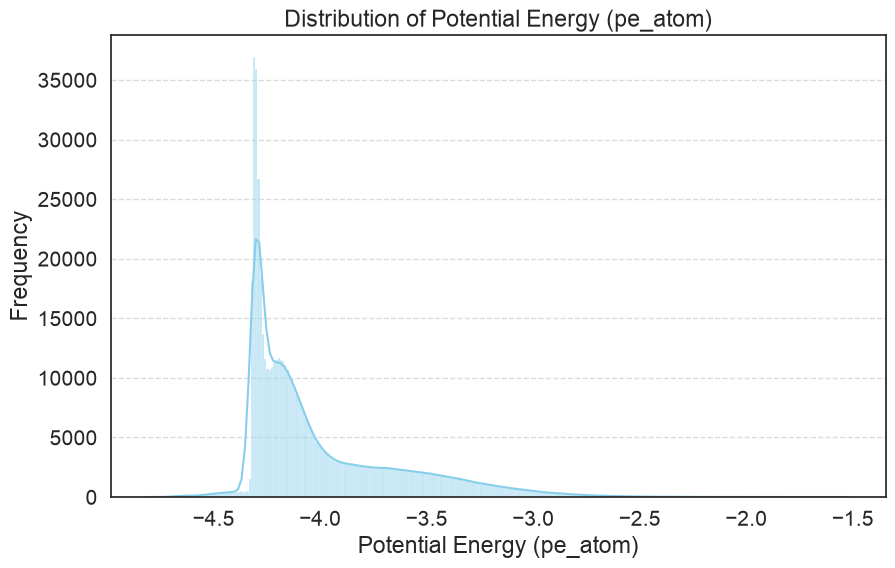

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(silicon_dataset['pe_atom'], kde=True, color='skyblue')
plt.title('Distribution of Potential Energy (pe_atom)')
plt.xlabel('Potential Energy (pe_atom)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Check for missing values in each column
missing_values = silicon_dataset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
timestep    0
box_x       0
box_y       0
box_z       0
atom_id     0
           ..
g2_35       0
g2_36       0
g2_37       0
g2_38       0
g2_39       0
Length: 84, dtype: int64


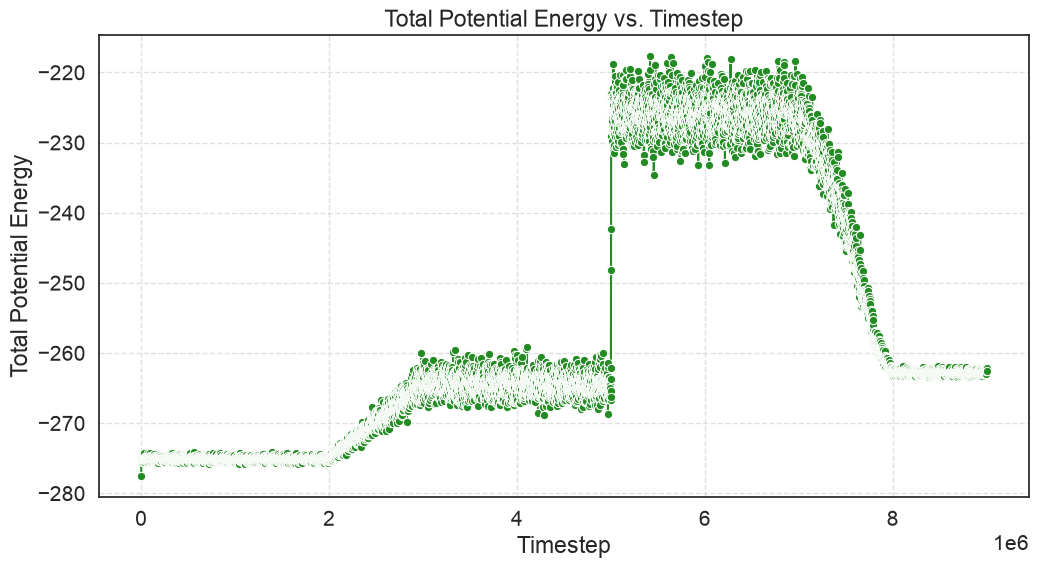

In [12]:
# Group by timestep and sum the potential energy of all atoms to get total energy
total_energy_per_step = silicon_dataset.groupby('timestep')['pe_atom'].sum().reset_index()

# Plot Total Energy vs Timestep
plt.figure(figsize=(12, 6))
sns.lineplot(data=total_energy_per_step, x='timestep', y='pe_atom', marker='o', color='forestgreen')
plt.title('Total Potential Energy vs. Timestep')
plt.xlabel('Timestep')
plt.ylabel('Total Potential Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🫪 **Converting Function**

In [13]:
@njit(parallel=False, fastmath=True)
def compute_symmetry_functions(coords_3d, eta_rad, Rc, Rs, lmbda, zeta, eta_ang = None, pbc=False, box_lengths = np.zeros(3), combine = False):
    """
    Computes G1 and G2 symmetry functions for each atom in each frame.

    Parameters:
    - coords_3d:    (num_frames, num_atoms, 3) array of coordinates.
    - box_lengths:  (3,) array containing the dimensions of the simulation box (Lx, Ly, Lz).
                    Must be passed as an array even if pbc=False (e.g., np.zeros(3)).
    - eta_rad:      1-D array of eta values for radial (G1) functions.
    - eta_ang:      1-D array of eta values for angular (G2) functions.
    - Rc:           cutoff radius.
    - Rs:           1-D array of radial shift values.
    - lmbda:        1-D array of lambda values for angular functions.
    - zeta:         1-D array of zeta values for angular functions.
    - pbc:          Boolean flag to enable/disable Periodic Boundary Conditions.
    """
    num_frames = coords_3d.shape[0]
    num_atoms  = coords_3d.shape[1]

    n_eta_rad = len(eta_rad)
    n_Rs      = len(Rs)
    if eta_ang is None:
        eta_ang = eta_rad.copy()  # Default to using the same eta values for angular functions
    n_eta_ang = len(eta_ang)
    n_zeta    = len(zeta)
    n_lmbda   = len(lmbda)

    num_radial   = n_eta_rad * n_Rs if combine else n_eta_rad
    num_angular  = n_eta_ang * n_zeta * n_lmbda
    num_sf       = num_radial + num_angular

    fingerprints = np.zeros((num_frames, num_atoms, num_sf), dtype=np.float64)
    
    Lx, Ly, Lz = box_lengths[0], box_lengths[1], box_lengths[2]

    for f in prange(num_frames):
        frame_coords = coords_3d[f]

        for i in range(num_atoms):
            xi, yi, zi = frame_coords[i, 0], frame_coords[i, 1], frame_coords[i, 2]

            for j in range(num_atoms):
                if i == j:
                    continue

                xj, yj, zj = frame_coords[j, 0], frame_coords[j, 1], frame_coords[j, 2]
                dx_ij = xi - xj
                dy_ij = yi - yj
                dz_ij = zi - zj
                
                # ── Conditionally Apply Minimum Image Convention (MIC) ──
                if pbc:
                    dx_ij -= Lx * np.round(dx_ij / Lx)
                    dy_ij -= Ly * np.round(dy_ij / Ly)
                    dz_ij -= Lz * np.round(dz_ij / Lz)

                rij = np.sqrt(dx_ij**2 + dy_ij**2 + dz_ij**2)

                if rij > Rc:
                    continue

                cut_ij = 0.5 * (np.cos(np.pi * rij / Rc) + 1.0)

                # ── G1 radial: loop over all (eta_rad, Rs) pairs ──────────────
                for e_idx in range(n_eta_rad):
                    eta_r = eta_rad[e_idx]
                    if combine:
                        for p in range(n_Rs):
                            rad_idx = e_idx * n_Rs + p
                            fingerprints[f, i, rad_idx] += (
                                np.exp(-eta_r * (rij - Rs[p]) ** 2) * cut_ij
                            )
                    else:
                        fingerprints[f, i, e_idx] += (
                            np.exp(-eta_rad[e_idx] * (rij - Rs[e_idx]) ** 2) * cut_ij
                        )

                # ── G2 angular: loop over k neighbours ───────────────────────
                for k in range(num_atoms):
                    if k == i or k == j:
                        continue

                    xk, yk, zk = frame_coords[k, 0], frame_coords[k, 1], frame_coords[k, 2]
                    dx_ik = xi - xk
                    dy_ik = yi - yk
                    dz_ik = zi - zk
                    
                    # ── Conditionally Apply Minimum Image Convention (MIC) ──
                    if pbc:
                        dx_ik -= Lx * np.round(dx_ik / Lx)
                        dy_ik -= Ly * np.round(dy_ik / Ly)
                        dz_ik -= Lz * np.round(dz_ik / Lz)

                    rik = np.sqrt(dx_ik**2 + dy_ik**2 + dz_ik**2)

                    if rik > Rc:
                        continue

                    # ── Triangle Consistency for jk ──
                    dx_jk = dx_ik - dx_ij
                    dy_jk = dy_ik - dy_ij
                    dz_jk = dz_ik - dz_ij
                    rjk = np.sqrt(dx_jk**2 + dy_jk**2 + dz_jk**2)

                    if rjk > Rc:
                        continue

                    cut_ik = 0.5 * (np.cos(np.pi * rik / Rc) + 1.0)
                    cut_jk = 0.5 * (np.cos(np.pi * rjk / Rc) + 1.0)

                    dot_product  = dx_ij * dx_ik + dy_ij * dy_ik + dz_ij * dz_ik
                    cos_theta    = dot_product / (rij * rik)
                    r2_sum       = rij ** 2 + rik ** 2 + rjk ** 2

                    # loop over all (eta_ang, zeta, lmbda) combinations
                    for ea_idx in range(n_eta_ang):
                        exp_term = np.exp(-eta_ang[ea_idx] * r2_sum)

                        for z_idx in range(n_zeta):
                            for l_idx in range(n_lmbda):
                                ang_idx = (
                                    num_radial
                                    + ea_idx * n_zeta * n_lmbda
                                    + z_idx  * n_lmbda
                                    + l_idx
                                )
                                fingerprints[f, i, ang_idx] += 2**(1 - zeta[z_idx]) * (
                                    (1.0 + lmbda[l_idx] * cos_theta) ** zeta[z_idx]
                                    * exp_term * cut_ij * cut_ik * cut_jk
                                )

    return fingerprints

In [14]:
import torch

# Same function as above but implemented in PyTorch for GPU acceleration and differentiability
def compute_symmetry_functions_vectorized(coords_3d, Rc, eta_rad, Rs, eta_ang, zeta, lmbda, pbc=False, box_lengths=None):
    """
    Versione ultra-veloce e differenziabile (Vettorizzata).
    Sfrutta le operazioni su tensori (broadcasting) eliminando i cicli for sugli atomi.
    """
    B, N, _ = coords_3d.shape
    device = coords_3d.device
    dtype = coords_3d.dtype

    # 1. Calcolo di tutti i vettori distanza in un colpo solo (B, N, N, 3)
    diff = coords_3d.unsqueeze(2) - coords_3d.unsqueeze(1)

    if pbc and box_lengths is not None:
        box = box_lengths.view(1, 1, 1, 3)
        diff = diff - box * torch.round(diff / box)

    # Matrice delle distanze (B, N, N)
    dist = torch.norm(diff, dim=-1)

    # 2. Funzione di Cutoff e Maschera
    fc = 0.5 * (torch.cos(torch.pi * dist / Rc) + 1.0)
    
    # Maschera per escludere gli atomi stessi (diagonale) e le distanze > Rc
    eye = torch.eye(N, dtype=torch.bool, device=device).unsqueeze(0) # (1, N, N)
    valid_ij = (dist <= Rc) & (~eye)
    fc = torch.where(valid_ij, fc, torch.zeros_like(fc))

    # 3. Funzioni Radiali G1
    eta_r = eta_rad.view(1, 1, 1, -1)
    Rs_v  = Rs.view(1, 1, 1, -1)
    dist_exp = dist.unsqueeze(-1) 
    fc_exp   = fc.unsqueeze(-1)     

    g1_terms = torch.exp(-eta_r * (dist_exp - Rs_v)**2) * fc_exp
    G1 = g1_terms.sum(dim=2) # Somma su j -> Risultato: (B, N, num_rad)

    # 4. Funzioni Angolari G2
    # Creiamo una griglia piatta di tutti i parametri angolari per calcolarli in parallelo
    grid_ea, grid_z, grid_l = torch.meshgrid(eta_ang, zeta, lmbda, indexing='ij')
    ea_flat = grid_ea.flatten().view(1, 1, 1, 1, -1)
    z_flat  = grid_z.flatten().view(1, 1, 1, 1, -1)
    l_flat  = grid_l.flatten().view(1, 1, 1, 1, -1)

    # Prepariamo le distanze per la tripletta i, j, k
    R_ij = dist.unsqueeze(3) # (B, N, N, 1)
    R_ik = dist.unsqueeze(2) # (B, N, 1, N)
    R_jk = dist.unsqueeze(1) # (B, 1, N, N)

    fc_ij = fc.unsqueeze(3)
    fc_ik = fc.unsqueeze(2)
    fc_jk = fc.unsqueeze(1)

    # Maschera per triplette valide (j!=i, k!=i, j!=k e tutte sotto Rc)
    valid_ik = valid_ij.unsqueeze(2) 
    valid_jk = valid_ij.unsqueeze(1) 
    j_neq_k  = ~torch.eye(N, dtype=torch.bool, device=device).view(1, 1, N, N)
    valid_ijk = valid_ij.unsqueeze(3) & valid_ik & valid_jk & j_neq_k

    # Calcolo dell'angolo (cos theta)
    vec_ij = diff.unsqueeze(3) 
    vec_ik = diff.unsqueeze(2) 
    dot = torch.sum(vec_ij * vec_ik, dim=-1) # Prodotto scalare
    cos_theta = dot / (R_ij * R_ik + 1e-8)   # Evita divisioni per zero

    # Calcolo dei termini di Behler-Parrinello
    exp_arg = R_ij**2 + R_ik**2 + R_jk**2 
    exp_term = torch.exp(-ea_flat * exp_arg.unsqueeze(-1)) 
    cos_term = (1.0 + l_flat * cos_theta.unsqueeze(-1))**z_flat

    ang_terms = (2.0**(1.0 - z_flat)) * cos_term * exp_term
    ang_terms = ang_terms * (fc_ij * fc_ik * fc_jk).unsqueeze(-1) # Applica i cutoff

    # Azzera i termini spuri non inclusi nella maschera
    ang_terms = torch.where(valid_ijk.unsqueeze(-1), ang_terms, torch.zeros_like(ang_terms))

    # Somma su j e k
    G2 = ang_terms.sum(dim=(2, 3)) # Risultato: (B, N, num_ang)

    # 5. Concatenazione finale
    return torch.cat([G1, G2], dim=-1)

In [15]:
if generate == True:
    Rc_val = 3.7712  # The exact SW cutoff for Silicon
    

    # # https://arxiv.org/abs/1804.02150 Imbalzano RULE Centered
    # indices_radial = np.array(range(0, N_RADIAL))
    # indices_angular = np.array(range(0, N_ANGULAR / 2))

    # eta_radial = ((N_RADIAL - 1) ** (indices_radial / (N_RADIAL - 1)) / Rc_val) ** 2
    # Rs_grid = np.zeros_like(eta_radial)
    # zeta_grid = np.array([1.0, 4.0, 16.0])
    # eta_angular = (((N_ANGULAR / 2) - 1) ** (indices_angular / ((N_ANGULAR / 2) - 1)) / Rc_val) ** 2
    # lambda_grid = np.array([-1.0, 1.0])


    # # https://arxiv.org/abs/1804.02150 Imbalzano RULE Shifted
    # indices_radial = np.array(range(0, N_RADIAL))
    # indices_angular = np.array(range(0, N_ANGULAR // 2))

    # Rs_grid = Rc_val / N_RADIAL ** (indices_radial / N_RADIAL)
    # eta_radial = np.zeros(N_RADIAL)  # Constant eta value for shifted radial functions
    # for i in range(len(Rs_grid) - 1):
    #     eta_radial[i] = 1.0 / (Rs_grid[i] - Rs_grid[i + 1]) ** 2
    # Rs_grid = np.flip(Rs_grid[1:])
    # eta_radial = np.flip(eta_radial)
    # zeta_grid   = np.array([1.0])
    # eta_angular = (((N_ANGULAR / 2) - 1) ** (indices_angular / ((N_ANGULAR / 2) - 1)) / Rc_val) ** 2
    # lambda_grid = np.array([-1.0, 1.0])


    # # https://arxiv.org/abs/1712.05861 Gastegger RULE Centered
    r_low = 2.0
    r_upp = 3.5
    # grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
    # dr_radial = (r_upp - r_low) / (N_RADIAL - 1)
    # grid_angular = np.linspace(r_low, r_upp, int(N_ANGULAR / 2))
    # dr_angular = (r_upp - r_low) / ((N_ANGULAR / 2) - 1)

    # Rs_grid = np.zeros(N_RADIAL)
    # eta_radial = 1.0 / (grid_radial ** 2) # Inverse square of the grid points for eta values
    # Angular symmetry function parameters
    eta_angular = np.array([0.001, 0.01, 0.05, 0.1])                     # Gentle decay for triplets
    lambda_grid = np.array([-1.0, 1.0])                 # Anchors at 0 and 180 degrees
    zeta_grid   = np.array([1.0, 2.0, 4.0, 8.0, 16.0])  # Resolution from broad to sharp
    

    # https://arxiv.org/abs/1712.05861 Gastegger RULE Shifted
    # r_low = 0.5
    # r_upp = Rc_val - 0.5
    grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
    dr_radial = (r_upp - r_low) / (N_RADIAL - 1)
    # grid_angular = np.linspace(r_low, r_upp, int(N_ANGULAR / 2))
    # dr_angular = (r_upp - r_low) / ((int(N_ANGULAR / 2) - 1))

    Rs_grid = grid_radial
    eta_radial = np.full(N_RADIAL, 1.0 / (2.0 * dr_radial**2))  # Constant eta value for shifted radial functions
    # zeta_grid   = np.array([1.0])
    # eta_angular = np.full(N_ANGULAR / 2, 1.0 / (2.0 * dr_angular**2))  # Constant eta value for shifted angular functions
    # lambda_grid = np.array([-1.0, 1.0])

    atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))
    coords_flat = silicon_dataset[['x', 'y', 'z']].values
    coords_3d = coords_flat.reshape(-1, atoms_per_frame, 3)
    n_frames = coords_3d.shape[0]

    num_radial  = len(eta_radial) #* len(Rs_grid)
    num_angular = len(eta_angular) * len(zeta_grid) * len(lambda_grid)
    num_sf      = num_radial + num_angular

    print(f"Found {n_frames} frames of {atoms_per_frame} atoms each.")
    print(f"Symmetry functions: {num_radial} radial + {num_angular} angular = {num_sf} total")

    # batch_size = 1
    # risultati_list = []

    # box_lengths = np.array([
    #     silicon_dataset['box_x'].iloc[0],
    #     silicon_dataset['box_y'].iloc[0],
    #     silicon_dataset['box_z'].iloc[0]
    # ])

    # for i in tqdm(range(0, n_frames, batch_size), desc="Computing symmetry functions"):
    #     batch_coords = coords_3d[i : i + batch_size]

    #     batch_res = compute_symmetry_functions(
    #         coords_3d=batch_coords,
    #         Rc=Rc_val,
    #         eta_rad=eta_radial,
    #         Rs=Rs_grid,
    #         zeta=zeta_grid,
    #         eta_ang=eta_angular,
    #         lmbda=lambda_grid,
    #         pbc=True,
    #         box_lengths=box_lengths
    #     )
    #     risultati_list.append(batch_res)

    eta_radial_t  = torch.tensor(eta_radial, dtype=torch.float32, device=device)
    Rs_grid_t     = torch.tensor(Rs_grid, dtype=torch.float32, device=device)
    eta_angular_t = torch.tensor(eta_angular, dtype=torch.float32, device=device)
    zeta_grid_t   = torch.tensor(zeta_grid, dtype=torch.float32, device=device)
    lambda_grid_t = torch.tensor(lambda_grid, dtype=torch.float32, device=device)
    
    box_lengths = np.array([
        silicon_dataset['box_x'].iloc[0],
        silicon_dataset['box_y'].iloc[0],
        silicon_dataset['box_z'].iloc[0]
    ])
    box_lengths_t = torch.tensor(box_lengths, dtype=torch.float32, device=device)

    batch_size = 2 
    risultati_list = []

    for i in tqdm(range(0, n_frames, batch_size), desc="Computing symmetry functions (Vectorized)"):
        # Estraiamo il batch e lo carichiamo sul device con requires_grad=True
        batch_coords = coords_3d[i : i + batch_size]
        batch_coords_tensor = torch.tensor(batch_coords, dtype=torch.float32, device=device)
        batch_coords_tensor.requires_grad_(True)

        # Chiamiamo la nuova funzione ultra-veloce passandole I TENSORI
        batch_res = compute_symmetry_functions_vectorized(
            coords_3d=batch_coords_tensor,
            Rc=Rc_val,
            eta_rad=eta_radial_t,
            Rs=Rs_grid_t,
            eta_ang=eta_angular_t,
            zeta=zeta_grid_t,
            lmbda=lambda_grid_t,
            pbc=True,
            box_lengths=box_lengths_t
        )
        
        # Per poterli mettere in un DataFrame Pandas dopo, stacchiamo i risultati dal grafo
        risultati_list.append(batch_res.detach().cpu().numpy())
        
        if device == torch.device("cuda"):
            torch.cuda.empty_cache()
        elif device == torch.device("mps"):
            torch.mps.empty_cache()

    risultati_3d = np.vstack(risultati_list)
    print("Computation completed! Formatting the dataframe...")

    num_symmetry_functions = risultati_3d.shape[2]
    symmetry_flat = risultati_3d.reshape(-1, num_symmetry_functions)

    symmetry_cols = [f'sf_{i}' for i in range(num_symmetry_functions)]
    symmetry_df   = pd.DataFrame(symmetry_flat, columns=symmetry_cols)

    g1_cols = symmetry_cols[:num_radial]
    g2_cols = symmetry_cols[num_radial:]
    g1_df   = symmetry_df[g1_cols].copy()
    g2_df   = symmetry_df[g2_cols].copy()
    g1_df.columns = [f'g1_{i}' for i in range(len(g1_df.columns))]
    g2_df.columns = [f'g2_{i}' for i in range(len(g2_df.columns))]

    silicon_dataset = pd.concat([silicon_dataset.reset_index(drop=True), g1_df, g2_df], axis=1)

    print(f"Symmetry functions added! G1:{g1_df.shape[1]} G2:{g2_df.shape[1]} Dataset shape: {silicon_dataset.shape}")
    silicon_dataset.to_csv(symmetry_dataset_path, index=False)
    print(f"Saved to {symmetry_dataset_path}")

## 🔄 **Data Preprocessing**

In [16]:
n_atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))
symmetry_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]

print("=== DATASET DIAGNOSTICS ===")
print(f"Frames totali: {silicon_dataset['timestep'].nunique()}")
print(f"Atomi per frame: {n_atoms_per_frame}")
print(f"Features: {len(symmetry_cols)} symmetry functions")
print(f"\npe_atom statistics:")
print(silicon_dataset['pe_atom'].describe())
print(f"\nRange pe_atom: {silicon_dataset['pe_atom'].max() - silicon_dataset['pe_atom'].min():.4f} eV")

# Check symmetry functions are not all zero or degenerate
sf_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]
sf_data = silicon_dataset[sf_cols]
print(f"\nSymmetry function statistics:")
std_threshold = 1e-10
low_std_cols = silicon_dataset[symmetry_cols].std().loc[lambda s: s < std_threshold].index.tolist()

print(f"Columns with zero variance: {(sf_data.std() < 1e-10).sum()}, {low_std_cols}")
print(f"Columns with NaN: {sf_data.isna().sum().sum()}")
print(f"Mean of all SF values: {sf_data.values.mean():.4f}")
print(f"Std of all SF values:  {sf_data.values.std():.4f}")

# std_threshold = 1e-10

# # Trova le colonne a bassa deviazione standard
# low_std_cols = silicon_dataset[symmetry_cols].std().loc[lambda s: s < std_threshold].index.tolist()

# print(f"Rimozione colonne con std < {std_threshold}: {low_std_cols}")
# silicon_dataset = silicon_dataset.drop(columns=low_std_cols)

=== DATASET DIAGNOSTICS ===
Frames totali: 9001
Atomi per frame: 64
Features: 72 symmetry functions

pe_atom statistics:
count    576064.000000
mean         -4.004276
std           0.359242
min          -4.817480
25%          -4.275050
50%          -4.142860
75%          -3.838490
max          -1.510620
Name: pe_atom, dtype: float64

Range pe_atom: 3.3069 eV

Symmetry function statistics:
Columns with zero variance: 0, []
Columns with NaN: 0
Mean of all SF values: 0.0454
Std of all SF values:  0.1378


In [17]:
n_atoms = np.unique(silicon_dataset['atom_id']).size

# --- THE FIX: Create a globally unique frame_id ---
# Because multiple LAMMPS files were concatenated, 'timestep' repeats.
# This creates a strictly unique ID for every contiguous 64-atom block.
silicon_dataset['frame_id'] = np.repeat(np.arange(len(silicon_dataset) // n_atoms), n_atoms)

# 1. Get unique frame_ids and split them
all_frames = silicon_dataset['frame_id'].unique()
train_frames, temp_frames = train_test_split(all_frames, test_size=0.10, random_state=SEED)
val_frames, test_frames = train_test_split(temp_frames, test_size=0.50, random_state=SEED)

# 2. Filter dataset and strictly sort to guarantee X and y alignment
train_df = silicon_dataset[silicon_dataset['frame_id'].isin(train_frames)].sort_values(['frame_id', 'atom_id'])
val_df = silicon_dataset[silicon_dataset['frame_id'].isin(val_frames)].sort_values(['frame_id', 'atom_id'])
test_df = silicon_dataset[silicon_dataset['frame_id'].isin(test_frames)].sort_values(['frame_id', 'atom_id'])

features_start_idx = silicon_dataset.columns.get_loc('g1_0')

# 3. Extract flattened X features for scaling
X_train_flat = train_df.iloc[:, features_start_idx:].values
X_val_flat = val_df.iloc[:, features_start_idx:].values
X_test_flat = test_df.iloc[:, features_start_idx:].values

# 4. Extract total energies per frame for y (Group by the unique frame_id!)
y_train_total = train_df.groupby('frame_id')['pe_atom'].sum().values
y_val_total = val_df.groupby('frame_id')['pe_atom'].sum().values
y_test_total = test_df.groupby('frame_id')['pe_atom'].sum().values

# 5. Scale features using the flattened arrays
feature_scaler = StandardScaler()
X_train_scaled_flat = feature_scaler.fit_transform(X_train_flat)
X_val_scaled_flat = feature_scaler.transform(X_val_flat)
X_test_scaled_flat = feature_scaler.transform(X_test_flat)

num_features = X_train_flat.shape[1]

# 6. RESHAPE X INTO 3D TENSORS: (num_frames, atoms_per_frame, num_features)
X_train_scaled = X_train_scaled_flat.reshape(-1, n_atoms, num_features)
X_val_scaled = X_val_scaled_flat.reshape(-1, n_atoms, num_features)
X_test_scaled = X_test_scaled_flat.reshape(-1, n_atoms, num_features)

# 7. Shift total target energies around 0
mean_total_energy = y_train_total.mean()
y_train_shifted = y_train_total - mean_total_energy
y_val_shifted = y_val_total - mean_total_energy
y_test_shifted = y_test_total - mean_total_energy

print(f"Shapes for PyTorch -> X_train: {X_train_scaled.shape}, y_train: {y_train_shifted.shape}")
print(f"Shifted target energies by {mean_total_energy:.4f} eV")

Shapes for PyTorch -> X_train: (8100, 64, 73), y_train: (8100,)
Shifted target energies by -256.3131 eV


In [18]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels) and push them directly to the GPU
def to_device_if_cuda(tensor, device):
    return tensor.to(device) if device.type == 'cuda' else tensor

# train_ds = TensorDataset(
#     to_device_if_cuda(torch.from_numpy(X_train_scaled).float(), device),
#     to_device_if_cuda(torch.from_numpy(y_train).float().unsqueeze(1), device)
# )
# val_ds = TensorDataset(
#     to_device_if_cuda(torch.from_numpy(X_val_scaled).float(), device),
#     to_device_if_cuda(torch.from_numpy(y_val).float().unsqueeze(1), device)
# )
# test_ds = TensorDataset(
#     to_device_if_cuda(torch.from_numpy(X_test_scaled).float(), device),
#     to_device_if_cuda(torch.from_numpy(y_test).float().unsqueeze(1), device)
# )

train_ds = TensorDataset (
    to_device_if_cuda(torch.from_numpy(X_train_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_train_shifted).float().unsqueeze(1), device)
)
val_ds = TensorDataset (
    to_device_if_cuda(torch.from_numpy(X_val_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_val_shifted).float().unsqueeze(1), device)
)
test_ds = TensorDataset (
    to_device_if_cuda(torch.from_numpy(X_test_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_test_shifted).float().unsqueeze(1), device)
)

In [19]:
def make_loader(ds, batch_size, shuffle, drop_last):
    if device.type == "cuda":
          return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                            num_workers=0,pin_memory=False)
    elif device.type == "mps":
        num_workers = min(8, os.cpu_count())
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                         num_workers=num_workers, persistent_workers=True, pin_memory=False,
                         prefetch_factor=4)
    else:  # cpu
        num_workers = min(8, os.cpu_count())
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                         num_workers=num_workers, persistent_workers=True, pin_memory=False,
                         prefetch_factor=4)

In [20]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [21]:
# We use shape[2] because X is now 3D: (frames, atoms, features)
input_features = X_train_scaled.shape[2] 

# We are predicting 1 target (Total Energy)
output_features = 1 

print(f"Input features per atom: {input_features}")
print(f"Output features: {output_features}")

for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Input features per atom: 73
Output features: 1


Features batch shape: torch.Size([128, 64, 73])
Labels batch shape: torch.Size([128, 1])


## 🛠️ **Model Building**

In [22]:
class FeedForwardNet(nn.Module):
    def __init__(self, in_features=input_features, out_features=1, hidden_layers=3, hidden_size=128, dropout_rate=0.0):
        super().__init__()
        
        # This sequential block represents the atomic neural network
        modules = [nn.Linear(in_features, hidden_size), nn.GELU()]
        for _ in range(hidden_layers - 1):
            modules.append(nn.Linear(hidden_size, hidden_size))
            if dropout_rate > 0:
                modules.append(nn.Dropout(dropout_rate))
            modules.append(nn.GELU())
        modules.append(nn.Linear(hidden_size, out_features))
        
        self.atomic_net = nn.Sequential(*modules)

    def forward(self, x):
        # x input shape: (batch_size_of_frames, atoms_per_frame, 72)
        
        # 1. Calculate individual atomic energy contributions
        atomic_energies = self.atomic_net(x) 
        # atomic_energies shape: (batch_size_of_frames, atoms_per_frame, 1)
        
        # 2. Sum the atomic energies to get the total predicted energy per frame
        total_energy = torch.sum(atomic_energies, dim=1)
        # total_energy shape: (batch_size_of_frames, 1)
        
        return total_energy

In [23]:
# Create model and display architecture with parameter count
model = FeedForwardNet(hidden_layers=HIDDEN_LAYERS, hidden_size=HIDDEN_SIZE, dropout_rate=DROPOUT_RATE).to(device)

experiment_name = ("experiment_hl"+str(HIDDEN_LAYERS)+"_hs"+str(HIDDEN_SIZE)+"_dr"+str(DROPOUT_RATE)+"_bs"+str(BATCH_SIZE)+"_lr"+str(LEARNING_RATE)+"_ep"+str(EPOCHS)+"_pt"+str(PATIENCE)+"_l2"+str(L2_LAMBDA)).replace('.', 'p')
# experiment_name += +"_"+str(lower)+"and"+str(upper)
timestamp = datetime.now().strftime("%m%d-%H%M")
experiment_name = f"{experiment_name}_{timestamp}"
print(f"Experiment name: {experiment_name}")

# Aggiungi il grafo su TensorBoard
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_features).to(device)
writer.add_graph(model, x)
writer.close()

# Summary su CPU e poi rimuovi gli hook
if device.type != "cuda":
    summary(model.to("cpu"), input_size=(input_features,))
    model = model.to(device)

    # Rimuovi tutti gli hook rimasti da torchsummary
    for module in model.modules():
        module._forward_hooks.clear()
        module._backward_hooks.clear()

# Compila solo su CUDA (su MPS l'overhead supera il guadagno)
if device.type == "cuda":
    # model = torch.compile(model)
    summary(model, input_size=(input_features,))

Experiment name: experiment_hl2_hs64_dr0p0_bs128_lr0p0001_ep1500_pt75_l20p0_0717-1148
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 64]           4,736
              GELU-2                   [-1, 64]               0
            Linear-3                   [-1, 64]           4,160
              GELU-4                   [-1, 64]               0
            Linear-5                    [-1, 1]              65
Total params: 8,961
Trainable params: 8,961
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.03
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [24]:
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_features).to(device)
writer.add_graph(model, x)
writer.close()

In [25]:
# model = torch.compile(model)

## 🧮 **Network Parameters**

In [26]:
# Set up loss function and optimizer
criterion = nn.MSELoss()
# criterion = nn.HuberLoss()


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Scheduler: either raise ReduceLROnPlateau patience
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-6   # was 3
)   

# Or switch to cosine warm restarts (often smoother)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     optimizer, T_0=300, T_mult=2
# )

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

## 🧠 **Model Training**

In [27]:
# Initialize best model tracking variables
best_model = None
best_performance = float('inf')

In [28]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Returns:
        tuple: (average_loss, RMSE) - Training loss and RMSE for this epoch
    """
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type in ('cuda', 'mps'))):
            logits = model(inputs)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        all_predictions.append(logits.detach().cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    # Convert to full concatenated numpy arrays first
    targets_flat = np.concatenate(all_targets)
    predictions_flat = np.concatenate(all_predictions)

    # Force both arrays to be exactly 2D: (num_samples, remaining_dimensions_flattened)
    targets_flat = targets_flat.reshape(targets_flat.shape[0], -1)
    predictions_flat = predictions_flat.reshape(predictions_flat.shape[0], -1)

    epoch_rmse = np.sqrt(mean_squared_error(targets_flat, predictions_flat))

    return epoch_loss, epoch_rmse

In [29]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Returns:
        tuple: (average_loss, RMSE) - Validation loss and RMSE for this epoch
    """
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type in ('cuda', 'mps'))):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            all_predictions.append(logits.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    # Convert to full concatenated numpy arrays first
    targets_flat = np.concatenate(all_targets)
    predictions_flat = np.concatenate(all_predictions)

    # Force both arrays to be exactly 2D: (num_samples, remaining_dimensions_flattened)
    targets_flat = targets_flat.reshape(targets_flat.shape[0], -1)
    predictions_flat = predictions_flat.reshape(predictions_flat.shape[0], -1)

    epoch_rmse = np.sqrt(mean_squared_error(targets_flat, predictions_flat))

    return epoch_loss, epoch_rmse

In [30]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_rmse", mode='min',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_rmse")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_rmse': [], 'val_rmse': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    best_val_rmse_print = float('inf')

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_rmse = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_rmse = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Step the scheduler based on validation loss
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
            scheduler.step()

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_rmse'].append(train_rmse)
        training_history['val_rmse'].append(val_rmse)

        # Check for improvement in val_rmse specifically for printing logic
        is_val_rmse_improvement = False
        if val_rmse < best_val_rmse_print:
            best_val_rmse_print = val_rmse
            is_val_rmse_improvement = True

        # Determine whether to print based on verbose setting
        should_print = False
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            should_print = True
        elif verbose == -1 and is_val_rmse_improvement:
            should_print = True
        elif verbose < -1 and (epoch % abs(verbose) == 0 or is_val_rmse_improvement):
            should_print = True

        # Print progress
        if should_print:
            # Add a visual flag if printing was triggered by an improvement while using a negative verbose

            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, RMSE={train_rmse:.4f} | "
                  f"Val: Loss={val_loss:.4f}, RMSE={val_rmse:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "./models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("./models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "./models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [31]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=-10,
    experiment_name=experiment_name
    )

# Update best model if current performance is superior
if training_history['val_rmse'][-1] < best_performance:
    best_model = model
    best_performance = training_history['val_rmse'][-1]

Training 1500 epochs...
Epoch   1/1500 | Train: Loss=97.8013, RMSE=9.8895 | Val: Loss=22.2634, RMSE=4.7184
Epoch   2/1500 | Train: Loss=11.8055, RMSE=3.4359 | Val: Loss=3.4437, RMSE=1.8557
Epoch   3/1500 | Train: Loss=2.5997, RMSE=1.6124 | Val: Loss=2.4879, RMSE=1.5773
Epoch   4/1500 | Train: Loss=2.1230, RMSE=1.4571 | Val: Loss=2.1549, RMSE=1.4679
Epoch   5/1500 | Train: Loss=1.9041, RMSE=1.3799 | Val: Loss=1.9531, RMSE=1.3976
Epoch   7/1500 | Train: Loss=1.6313, RMSE=1.2772 | Val: Loss=1.7290, RMSE=1.3149
Epoch   9/1500 | Train: Loss=1.5322, RMSE=1.2378 | Val: Loss=1.6428, RMSE=1.2817
Epoch  10/1500 | Train: Loss=1.4696, RMSE=1.2123 | Val: Loss=1.5404, RMSE=1.2411
Epoch  11/1500 | Train: Loss=1.4236, RMSE=1.1931 | Val: Loss=1.4685, RMSE=1.2118
Epoch  13/1500 | Train: Loss=1.3590, RMSE=1.1658 | Val: Loss=1.3968, RMSE=1.1819
Epoch  16/1500 | Train: Loss=1.2980, RMSE=1.1393 | Val: Loss=1.2610, RMSE=1.1230
Epoch  17/1500 | Train: Loss=1.2646, RMSE=1.1246 | Val: Loss=1.2605, RMSE=1.1227
E

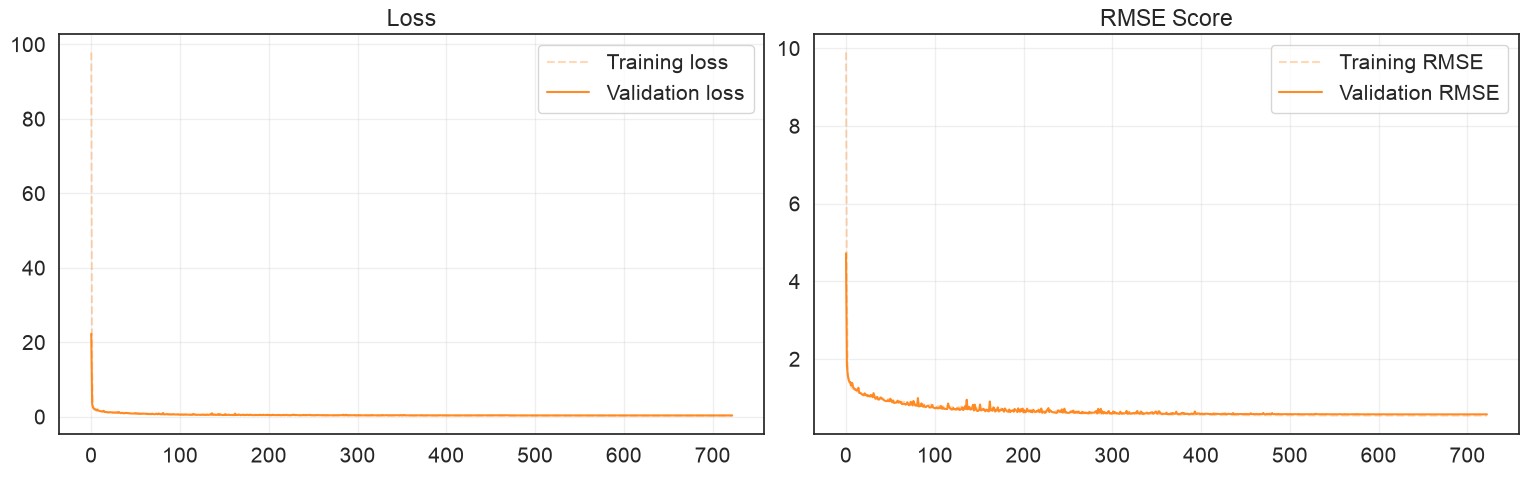

In [32]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_rmse'], label='Training RMSE', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_rmse'], label='Validation RMSE', alpha=0.9, color='#ff7f0e')
ax2.set_title('RMSE Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Mean Absolute Error (MAE): 0.3454
Root Mean Squared Error (RMSE):  0.5723
R-squared (R2) Score:      0.9992


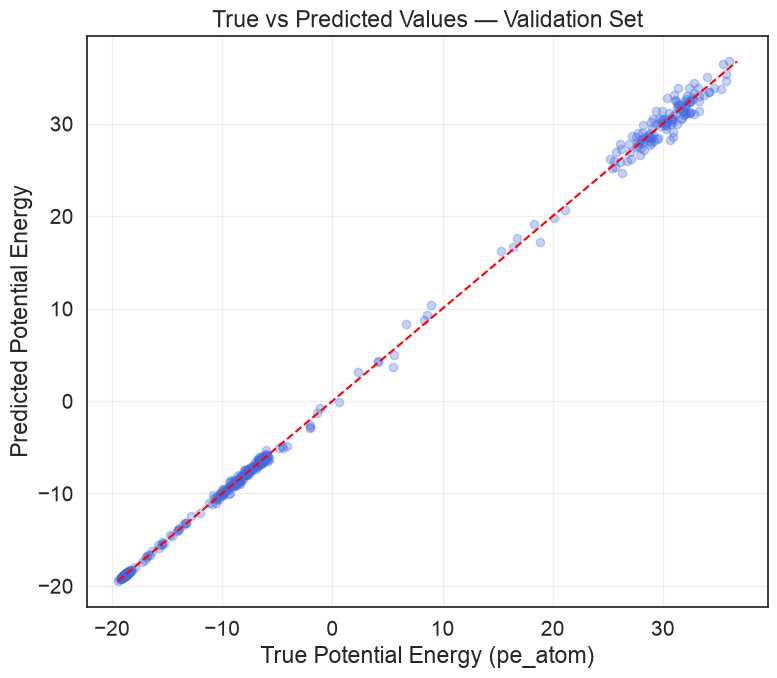

In [33]:
# @title Evaluate Regression Performance
val_preds, val_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)

        val_preds.append(logits.cpu().numpy())
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds, axis=0)
val_targets = np.concatenate(val_targets, axis=0)

# Calculate overall validation metrics
val_mae = mean_absolute_error(val_targets, val_preds)
val_mse = np.sqrt(mean_squared_error(val_targets, val_preds))
val_r2 = r2_score(val_targets, val_preds)

print(f"Mean Absolute Error (MAE): {val_mae:.4f}")
print(f"Root Mean Squared Error (RMSE):  {val_mse:.4f}")
print(f"R-squared (R2) Score:      {val_r2:.4f}")

# Generate Scatter Plot: True vs Predicted
plt.figure(figsize=(8, 7))
plt.scatter(val_targets, val_preds, alpha=0.3, color='royalblue')

# Plot the ideal prediction line (y = x)
min_val = min(val_targets.min(), val_preds.min())
max_val = max(val_targets.max(), val_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Validation Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🕹️ **Inference**

In [34]:
test_preds_shifted, test_targets_shifted = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions (these are shifted, centered near 0)
        logits = best_model(xb)

        # Store batch results
        test_preds_shifted.append(logits.cpu().numpy())
        test_targets_shifted.append(yb.cpu().numpy())

# Combine all batches into single arrays
test_preds_shifted = np.concatenate(test_preds_shifted)
test_targets_shifted = np.concatenate(test_targets_shifted)
# test_preds = test_preds_shifted + mean_energy
# test_targets = test_targets_shifted + mean_energy
test_preds = test_preds_shifted + mean_total_energy
test_targets = test_targets_shifted + mean_total_energy

Mean Absolute Error (MAE) over the test set: 0.3463
Root Mean Squared Error (RMSE) over the test set:  0.5562
R-squared (R2) score over the test set:      0.9992
Root Mean Squared Error (RMSE) per atom over the test set:  8.6903 meV/atom


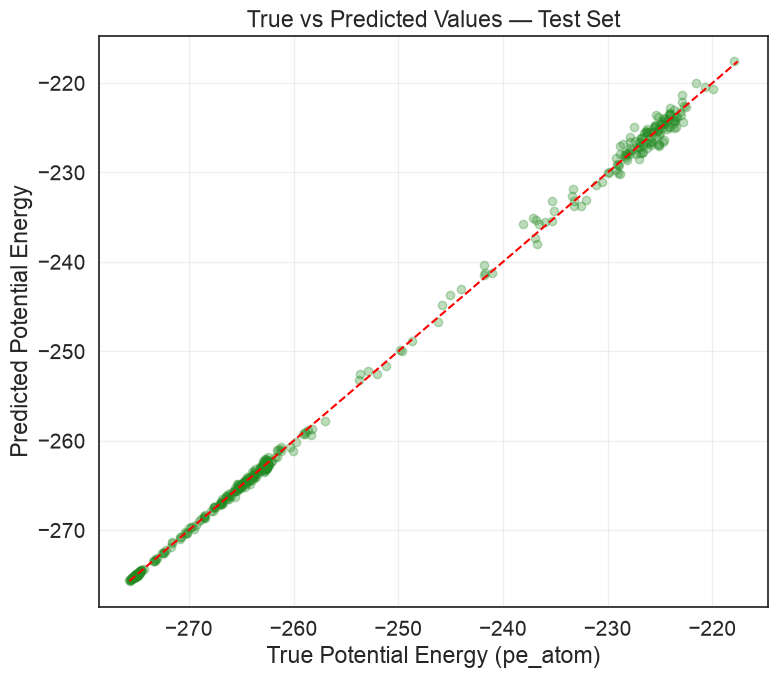

In [35]:
# Calculate overall test metrics for regression
test_mae = mean_absolute_error(test_targets, test_preds)
test_mse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_r2 = r2_score(test_targets, test_preds)

print(f"Mean Absolute Error (MAE) over the test set: {test_mae:.4f}")
print(f"Root Mean Squared Error (RMSE) over the test set:  {test_mse:.4f}")
print(f"R-squared (R2) score over the test set:      {test_r2:.4f}")
print(f"Root Mean Squared Error (RMSE) per atom over the test set:  {test_mse/n_atoms * 1000:.4f} meV/atom")

# Generate Scatter Plot: True vs Predicted for the Test Set
plt.figure(figsize=(8, 7))
# Using a different color (e.g., forestgreen) to distinguish from the validation plot
plt.scatter(test_targets, test_preds, alpha=0.3, color='forestgreen')

# Plot the ideal prediction line (y = x) where true == predicted
min_val = min(test_targets.min(), test_preds.min())
max_val = max(test_targets.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Test Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save experiment results to history.txt
with open('history.txt', 'a') as f:
    f.write(f"{experiment_name}\tRMSE: {test_mse:.4f}\n")

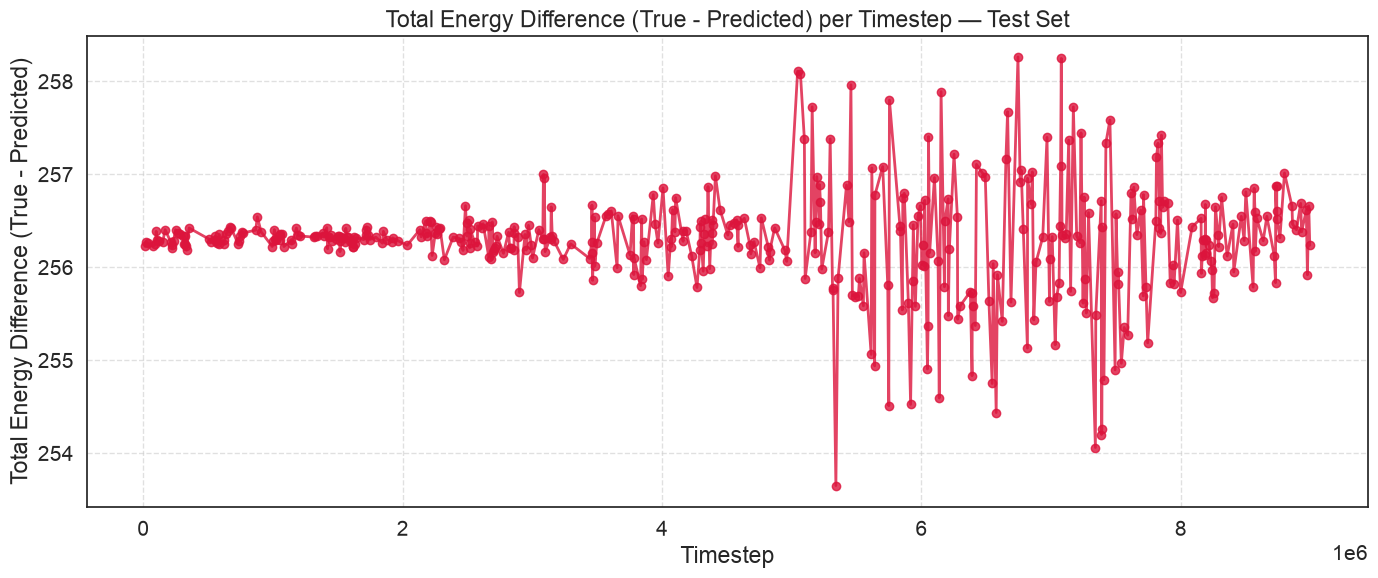

Frame-Level Total Energy Error Statistics:


count    451.000000
mean     256.293561
std        0.556453
min      253.650974
25%      256.152237
50%      256.320997
75%      256.488181
max      258.262461
Name: energy_diff, dtype: float64

In [36]:
# 1. Recupera i timestep per l'asse X
test_timesteps = test_df.groupby('frame_id')['timestep'].first().values

# 2. Usa i valori FISICI (reali), ignorando lo shift usato per l'addestramento
# Presumendo che test_preds contenga le predizioni grezze del modello
test_preds_physical = test_preds.flatten() + mean_total_energy 

# 3. Crea il DataFrame con i valori fisici corretti
energy_per_timestep = pd.DataFrame({
    'timestep': test_timesteps, 
    'true_energy': y_test_total.flatten(),       # <- Energia fisica reale
    'predicted_energy': test_preds_physical      # <- Energia predetta reale
}).sort_values('timestep')

# 4. Calcola la differenza (che rimarrà identica, ma le colonne sopra avranno senso)
energy_per_timestep['energy_diff'] = energy_per_timestep['true_energy'] - energy_per_timestep['predicted_energy']

# --- Il resto del codice (grafico e tolleranze) rimane IDENTICO ---
plt.figure(figsize=(14, 6))
plt.plot(
    energy_per_timestep['timestep'],
    energy_per_timestep['energy_diff'],
    marker='o',
    linestyle='-',
    color='crimson',
    linewidth=2,
    alpha=0.8
)

n_atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))

# Soglia di accuratezza chimica (es. 5 meV/atomo)
# lower_obj = - 5e-3 * n_atoms_per_frame
# upper_obj = 5e-3 * n_atoms_per_frame

# plt.axhspan(lower_obj, upper_obj, color='lightgray', alpha=0.3)
# plt.axhline(y=lower_obj, color='black', linestyle='--', alpha=0.7)
# plt.axhline(y=upper_obj, color='black', linestyle='--', alpha=0.7)

# plt.axhline(y=0, color='black', linestyle='-', alpha=1.0)

plt.title('Total Energy Difference (True - Predicted) per Timestep — Test Set')
plt.xlabel('Timestep')
plt.ylabel('Total Energy Difference (True - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Frame-Level Total Energy Error Statistics:")
display(energy_per_timestep['energy_diff'].describe())

## 💪🏻 Forces

In [37]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error
from tqdm import tqdm

# 1. Set the best model to evaluation mode
best_model.eval()

Rc_val = 3.7712
r_low = 2.0
r_upp = 3.5

eta_angular = np.array([0.001, 0.01, 0.05, 0.1])                     # Gentle decay for triplets
lambda_grid = np.array([-1.0, 1.0])                 # Anchors at 0 and 180 degrees
zeta_grid   = np.array([1.0, 2.0, 4.0, 8.0, 16.0])  # Resolution from broad to sharp

grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
dr_radial = (r_upp - r_low) / (N_RADIAL - 1)

Rs_grid = grid_radial
eta_radial = np.full(N_RADIAL, 1.0 / (2.0 * dr_radial**2))



# Convert symmetry function parameters to tensors
eta_radial_t  = torch.tensor(eta_radial, dtype=torch.float32, device=device)
Rs_grid_t     = torch.tensor(Rs_grid, dtype=torch.float32, device=device)
eta_angular_t = torch.tensor(eta_angular, dtype=torch.float32, device=device)
zeta_grid_t   = torch.tensor(zeta_grid, dtype=torch.float32, device=device)
lambda_grid_t = torch.tensor(lambda_grid, dtype=torch.float32, device=device)

# 3. Extract coordinates (x,y,z) and true forces (fx,fy,fz) from the validation dataframe
coords_val = val_df[['x', 'y', 'z']].values.reshape(-1, 64, 3)
forces_true_val = val_df[['fx', 'fy', 'fz']].values.reshape(-1, 64, 3)

box_lengths_t = torch.tensor([val_df['box_x'].iloc[0], val_df['box_y'].iloc[0], val_df['box_z'].iloc[0]], dtype=torch.float32, device=device)

n_frames_val = coords_val.shape[0]
all_pred_cartesians = []
all_true_cartesians = []

# Use a small batch size to prevent MPS memory saturation
batch_size_val = 2 

for i in tqdm(range(0, n_frames_val, batch_size_val), desc="Extracting Cartesian Forces"):
    batch_coords = coords_val[i : i + batch_size_val]
    batch_forces_true = forces_true_val[i : i + batch_size_val]
    
    # A. Cartesian position tensor with requires_grad=True
    R_tensor = torch.tensor(batch_coords, dtype=torch.float32, device=device)
    R_tensor.requires_grad_(True)
    
    # B. Recompute symmetry functions on-the-fly to keep the computation graph intact
    G_features = compute_symmetry_functions_vectorized(
        coords_3d=R_tensor,
        Rc=Rc_val,
        eta_rad=eta_radial_t,
        Rs=Rs_grid_t,
        eta_ang=eta_angular_t,
        zeta=zeta_grid_t,
        lmbda=lambda_grid_t,
        pbc=True,
        box_lengths=box_lengths_t
    )

    
    # C. Apply feature scaling using the scaler parameters from training
    mean_t = torch.tensor(feature_scaler.mean_, dtype=torch.float32, device=device)
    scale_t = torch.tensor(feature_scaler.scale_, dtype=torch.float32, device=device)
    
    # We need to match the input shape exactly to feature_scaler.n_features_in_
    expected_dim = feature_scaler.n_features_in_
    current_dim = G_features.shape[-1]
    
    if current_dim < expected_dim:
        # Pad with zeros to reach the expected dimensionality
        padding = torch.zeros((*G_features.shape[:-1], expected_dim - current_dim), 
                              device=device, dtype=torch.float32)
        G_features = torch.cat([G_features, padding], dim=-1)
    elif current_dim > expected_dim:
        # Truncate if we have too many
        G_features = G_features[..., :expected_dim]
    
    # Scale the aligned features
    G_scaled = (G_features - mean_t) / scale_t
    
    # D. Forward pass
    E_pred = best_model(G_scaled)
    
    # E. True Cartesian gradient calculation (F = - dE/dR)
    F_pred = -torch.autograd.grad(
        outputs=E_pred,
        inputs=R_tensor,
        grad_outputs=torch.ones_like(E_pred),
        create_graph=False,
        retain_graph=False
    )[0]
    
    all_pred_cartesians.append(F_pred.detach().cpu().numpy())
    all_true_cartesians.append(batch_forces_true)
    
    # Clear MPS cache to prevent memory buildup
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

# 4. Concatenate and calculate RMSE on Cartesian forces
all_pred_cartesians = np.concatenate(all_pred_cartesians, axis=0)
all_true_cartesians = np.concatenate(all_true_cartesians, axis=0)

rmse_forces = np.sqrt(mean_squared_error(all_true_cartesians.flatten(), all_pred_cartesians.flatten()))

print("\n" + "="*50)
print(f"📊 FORCE EVALUATION RESULTS (Energy Model vs Stillinger-Weber)")
print(f"Predicted forces shape: {all_pred_cartesians.shape}")
print(f"RMSE on Cartesian Forces: {rmse_forces:.4f} eV/Å")
print("="*50)

Extracting Cartesian Forces: 100%|██████████| 225/225 [01:03<00:00,  3.54it/s]


📊 FORCE EVALUATION RESULTS (Energy Model vs Stillinger-Weber)
Predicted forces shape: (450, 64, 3)
RMSE on Cartesian Forces: 1.2153 eV/Å


## 📈 Molecular Dynamics

In [ ]:
atomic_mass_Si = 28.0855 
# Temperature initialization
temperature_desired = 300.0  # K

N_STEPS = 10000
dt = 1e-3  # Time step in picoseconds

FORCE_CONVERSION = 9648.5332

In [ ]:
# Initial Velocities are sampled from a Maxwell-Boltzmann distribution
kB = 1.380649e-23
amu_to_kg = 1.66053906660e-27
A_per_ps_to_m_per_s = 1e2

sigma_m_s = np.sqrt(kB * temperature_desired / (atomic_mass_Si * amu_to_kg))
sigma_A_ps = sigma_m_s / A_per_ps_to_m_per_s

velocities = rng.normal(loc=0.0, scale=sigma_A_ps, size=(n_atoms, 3))

# remove center-of-mass drift
velocities -= velocities.mean(axis=0, keepdims=True)

# rescale to match the target temperature exactly
velocities_m_s = velocities * A_per_ps_to_m_per_s
current_T = (atomic_mass_Si * amu_to_kg * np.mean(velocities_m_s**2)) / kB
velocities *= np.sqrt(temperature_desired / current_T)

positions = silicon_dataset[['x', 'y', 'z']].iloc[:n_atoms].values.copy() # Takes the first frame's positions

box_lengths_np = np.array([silicon_dataset['box_x'].iloc[0], 
                           silicon_dataset['box_y'].iloc[0], 
                           silicon_dataset['box_z'].iloc[0]])

output_dynamic_filename = f"md_simulation_{experiment_name}.xyz"

In [ ]:
def compute_nn_forces(pos_numpy):
    R_tensor = torch.tensor(pos_numpy, dtype=torch.float32, device=device)
    R_tensor.requires_grad_(True)

    G_features = compute_symmetry_functions_vectorized(
        coords_3d=R_tensor.unsqueeze(0), # Aggiunge la dimensione del batch: (1, N, 3)
        Rc=Rc_val,
        eta_rad=eta_radial_t,
        Rs=Rs_grid_t,
        eta_ang=eta_angular_t,
        zeta=zeta_grid_t,
        lmbda=lambda_grid_t,
        pbc=True,
        box_lengths=box_lengths_t
    )

    mean_t = torch.tensor(feature_scaler.mean_, dtype=torch.float32, device=device)
    scale_t = torch.tensor(feature_scaler.scale_, dtype=torch.float32, device=device)
    
    expected_dim = feature_scaler.n_features_in_
    current_dim = G_features.shape[-1]
    
    if current_dim < expected_dim:
        padding = torch.zeros((*G_features.shape[:-1], expected_dim - current_dim), 
                              device=device, dtype=torch.float32)
        G_features = torch.cat([G_features, padding], dim=-1)
    elif current_dim > expected_dim:
        G_features = G_features[..., :expected_dim]
    
    G_scaled = (G_features - mean_t) / scale_t
    E_pred = best_model(G_scaled)

    F_pred = -torch.autograd.grad(
        outputs=E_pred,
        inputs=R_tensor,
        grad_outputs=torch.ones_like(E_pred),
        create_graph=False,
        retain_graph=False
    )[0]
    
    # Rimuove la dimensione del batch e converte in numpy
    return F_pred.squeeze(0).detach().cpu().numpy()

In [41]:
current_forces = compute_nn_forces(positions)

trajectory_velocities = []

# Inizializza il file XYZ
with open(output_dynamic_filename, 'w') as f:
    pass 

for i in tqdm(range(N_STEPS), desc="Running MD Simulation"):
    
    # STEP 1: Aggiorna le velocità per mezzo dt usando le forze correnti
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt
    
    # STEP 2: Aggiorna le posizioni per un intero dt
    positions += velocities * dt
    
    # Applica Periodic Boundary Conditions (wrapping dentro il box)
    positions = positions % box_lengths_np
    
    # STEP 3: Calcola le NUOVE forze basate sulle nuove posizioni
    current_forces = compute_nn_forces(positions)
    
    # STEP 4: Aggiorna di nuovo le velocità per l'altro mezzo dt
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt
    
    trajectory_velocities.append(velocities.copy())
    
    # Log della traiettoria ogni 50 step
    if i % 10 == 0:
        with open(output_dynamic_filename, 'a') as f:
            f.write(f"{n_atoms}\n")
            f.write(f"Step {i}\n")
            for atom_id in range(n_atoms):
                x, y, z = positions[atom_id]
                f.write(f"Si {x:.6f} {y:.6f} {z:.6f}\n")

trajectory_velocities = np.array(trajectory_velocities)

Running MD Simulation:   0%|          | 0/10000 [00:00<?, ?it/s]


ValueError: output array is read-only

## 🔥MÜLLER-PLATHE

In [ ]:
# Muller-Plathe Reverse NEMD Parameters

# Right parameters, but it take 9 hours to compute
# N_STEPS = 2000000
# N_SLABS = 20             
# SWAP_INTERVAL = 100    
# EQUILIBRATION_STEPS = 100000    

N_STEPS = 100000
N_SLABS = 20                    # Number slabs along the Z-axis for temperature profiling
SWAP_INTERVAL = 50              # Interval (in MD steps) to perform the Müller-Plathe velocity swap
EQUILIBRATION_STEPS = 20000     # Steps to allow the system to equilibrate before sampling temperatures

hot_slab_idx = N_SLABS // 2 # Center slab (z=Lz/2) for heating
cold_slab_idx = 0           # Bottom slab (z=0) for cooling

# Variables to trace energy exchange and slab temperatures
total_energy_exchanged_Joules = 0.0
slab_temperatures_accum = np.zeros(N_SLABS)
slab_counts = np.zeros(N_SLABS)
samples_taken = 0

# Dimension of the simulation box along Z and slab thickness
Lz = box_lengths_np[2]
slab_thickness = Lz / N_SLABS
Area = box_lengths_np[0] * box_lengths_np[1] # Area XY in Å^2
Area_m2 = Area * 1e-20                       # Area XY in m^2


In [ ]:
# Loops over MD steps with Müller-Plathe velocity swapping and temperature sampling
current_forces = compute_nn_forces(positions)

for i in tqdm(range(N_STEPS), desc="MD Simulation with Müller-Plathe"):
    
    # Velocity Verlet Integration half-step
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt
    positions += velocities * dt
    positions = positions % box_lengths_np
    
    # Müller-Plathe Velocity Swapping
    # Determine which slab each atom belongs to based on its Z-coordinate
    z_coords = positions[:, 2]
    slab_assignments = (z_coords / slab_thickness).astype(int) % N_SLABS
    
    if i % SWAP_INTERVAL == 0:
        # Find atoms in the hot and cold slabs
        hot_slab_atoms = np.where(slab_assignments == hot_slab_idx)[0]
        cold_slab_atoms = np.where(slab_assignments == cold_slab_idx)[0]
        
        if len(hot_slab_atoms) > 0 and len(cold_slab_atoms) > 0:
            # Compute squared velocities for atoms in hot and cold slabs
            v2_hot = np.sum(velocities[hot_slab_atoms]**2, axis=1)
            v2_cold = np.sum(velocities[cold_slab_atoms]**2, axis=1)
            
            # Find the indices of the coldest atom in the hot slab and the hottest atom in the cold slab
            idx_coldest_in_hot = hot_slab_atoms[np.argmin(v2_hot)]
            idx_hottest_in_cold = cold_slab_atoms[np.argmax(v2_cold)]
            
            v2_min_hot = np.min(v2_hot)
            v2_max_cold = np.max(v2_cold)
            
            # Make the swap only if the coldest in hot is colder than the hottest in cold
            if v2_max_cold > v2_min_hot:
                # Compute the energy exchanged during the swap in Joules as
                # $$\Delta E = \frac{1}{2} m v_{\text{hot}}^2 - \frac{1}{2} m v_{\text{cold}}^2$$
                v_max_cold_ms = np.sqrt(v2_max_cold) * 100.0
                v_min_hot_ms = np.sqrt(v2_min_hot) * 100.0
                mass_kg = atomic_mass_Si * amu_to_kg
                
                delta_E = 0.5 * mass_kg * (v_max_cold_ms**2 - v_min_hot_ms**2)
                total_energy_exchanged_Joules += delta_E
                
                # Swap the velocities of the identified atoms
                temp_v = velocities[idx_coldest_in_hot].copy()
                velocities[idx_coldest_in_hot] = velocities[idx_hottest_in_cold]
                velocities[idx_hottest_in_cold] = temp_v

    # Velocity Verlet Integration full-step
    current_forces = compute_nn_forces(positions)
    accelerations = (current_forces / atomic_mass_Si) * FORCE_CONVERSION
    velocities += 0.5 * accelerations * dt

    # Temperature Sampling for Each Slab
    # Start sampling after the equilibration period to ensure accurate temperature readings
    if i > EQUILIBRATION_STEPS:
        for s in range(N_SLABS):
            atoms_in_s = np.where(slab_assignments == s)[0]
            if len(atoms_in_s) > 0:
                v_sq = np.sum(velocities[atoms_in_s]**2)
                v_m_s_sq = v_sq * (100.0**2) # Convert from Å/ps to m/s
                # T = (m * v^2) / (3 * N * kB)
                T_slab = (atomic_mass_Si * amu_to_kg * v_m_s_sq) / (3 * len(atoms_in_s) * kB)
                
                slab_temperatures_accum[s] += T_slab
                slab_counts[s] += 1
        samples_taken += 1

MD Simulation with Müller-Plathe: 100%|██████████| 100000/100000 [28:59<00:00, 57.49it/s]


In [ ]:
# Compute average temperatures for each slab after the simulations
indexs = ~np.isnan(slab_temperatures_accum)
slab_temperatures_accum_valid = slab_temperatures_accum.copy()
slab_temperatures_accum_valid[~indexs] = 0.0
avg_slab_temperatures = slab_temperatures_accum_valid / slab_counts
z_centers = (np.arange(N_SLABS) + 0.5) * slab_thickness # Z-coordinates of slab centers

# Compute the heat flux Jz using the total energy exchanged and the time measured
# $$J_z = \frac{\sum \Delta E}{2 t A}$$ 2 factor for pbc
# Total time measured in seconds (dt is in picoseconds, so convert to seconds)
time_measured_s = (N_STEPS - EQUILIBRATION_STEPS) * dt * 1e-12 
Jz = total_energy_exchanged_Joules / (2 * time_measured_s * Area_m2) 
print(f"Thermal flux Jz: {Jz:.2e} W/m^2")

Thermal flux Jz: 4.51e+10 W/m^2


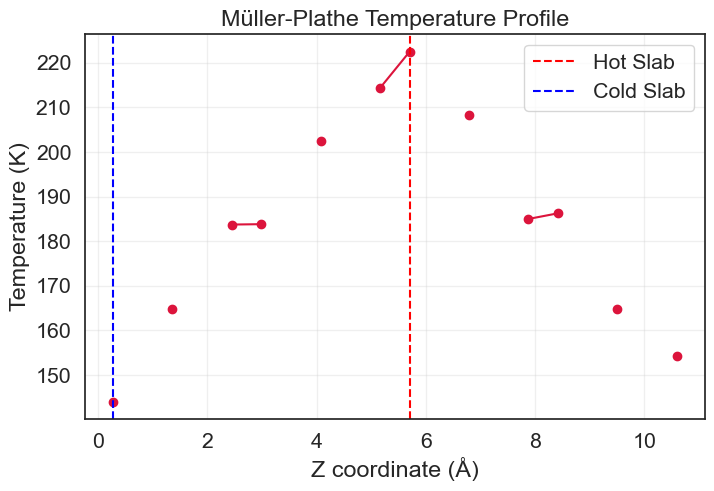

In [ ]:
# Plot the temperature profile along the Z-axis

plt.figure(figsize=(8, 5))
plt.plot(z_centers, avg_slab_temperatures, 'o-', color='crimson')
plt.axvline(x=z_centers[hot_slab_idx], color='red', linestyle='--', label='Hot Slab')
plt.axvline(x=z_centers[cold_slab_idx], color='blue', linestyle='--', label='Cold Slab')
plt.xlabel('Z coordinate (Å)')
plt.ylabel('Temperature (K)')
plt.title('Müller-Plathe Temperature Profile')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Thermal Conductivity Calculation using Fourier's Law

# Search for the indices of the hot and cold slabs in the temperature profile
left_region_idx = np.arange(cold_slab_idx, hot_slab_idx + 1)
right_region_idx = np.arange(hot_slab_idx, N_SLABS)

# Extract the Z-coordinates and average temperatures for the left and right regions
z_left = z_centers[left_region_idx]
T_left = avg_slab_temperatures[left_region_idx]

z_right = z_centers[right_region_idx]
T_right = avg_slab_temperatures[right_region_idx]

# filters for empty slabs (NaN values) in the temperature profile
valid_left = ~np.isnan(T_left)
valid_right = ~np.isnan(T_right)
z_left_valid = z_left[valid_left]
T_left_valid = T_left[valid_left]

z_right_valid = z_right[valid_right]
T_right_valid = T_right[valid_right]

# Linear fitting to determine the temperature gradients in both regions
slope_left, intercept_left = np.polyfit(z_left_valid, T_left_valid, 1)
slope_right, intercept_right = np.polyfit(z_right_valid, T_right_valid, 1)
# Compute the mean temperature gradient (in K/Å) across the two regions
avg_gradient_K_per_A = (np.abs(slope_left) + np.abs(slope_right)) / 2.0
avg_gradient_K_per_m = avg_gradient_K_per_A * 1e10

# Fourier Law: k = Jz / (dT/dz)
thermal_conductivity = Jz / avg_gradient_K_per_m

print("-" * 40)
print(f"Mean temperature gradient: {avg_gradient_K_per_A:.2f} K/Å")
print(f"Thermal conductivity (k): {thermal_conductivity:.2f} W/(m*K)")
print("-" * 40)

----------------------------------------
Mean temperature gradient: 14.11 K/Å
Thermal conductivity (k): 0.32 W/(m*K)
----------------------------------------


## ⭕ Radial Distribution Function

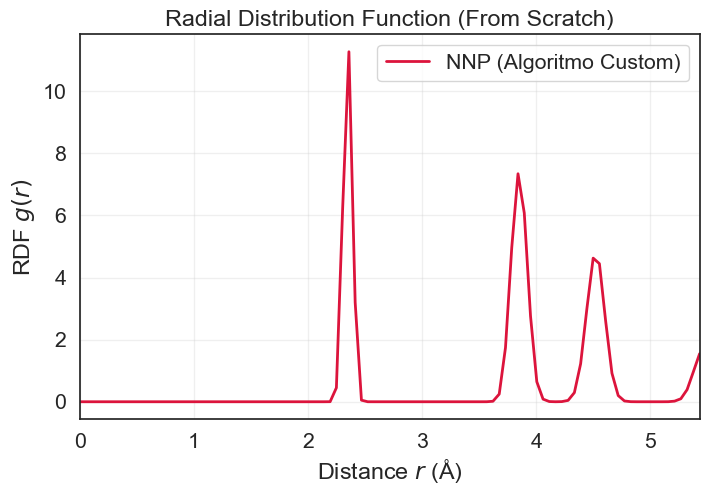

In [ ]:
trajectory = read(output_dynamic_filename, index=":")
box_lengths = np.array([10.862, 10.862, 10.862])
rmax = min(box_lengths) / 2.0
nbins = 100
dr = rmax / nbins

avg_rdf_histogram = np.zeros(nbins)

# Iterate through each frame in the trajectory to compute the RDF
for atoms in trajectory:
    coords = atoms.get_positions()
    n_atoms = len(coords)
    frame_rdf = np.zeros(nbins)
    
    for i in range(n_atoms):
        for j in range(i + 1, n_atoms):
            # Vettore distanza tra l'atomo i e l'atomo j
            diff = coords[i] - coords[j]
            
            # Apply periodic boundary conditions (PBC) using the minimum image convention,
            # if the distance exceeds half the box length, the "nearest" atom is the one in the adjacent periodic image.
            diff -= box_lengths * np.round(diff / box_lengths)
            dist = np.linalg.norm(diff)
            
            # If distance is within the maximum radius, update the RDF histogram
            if dist < rmax:
                bin_idx = int(dist / dr)
                if bin_idx < nbins:
                    frame_rdf[bin_idx] += 2 # Conta sia la coppia i-j che j-i
                    
    avg_rdf_histogram += frame_rdf

# Average the RDF histogram over all frames
avg_rdf_histogram /= len(trajectory)

# Normalize the RDF histogram to account for the volume of the spherical shells and the ideal gas density
volume = np.prod(box_lengths)
rho = n_atoms / volume
distances = np.linspace(0, rmax, nbins)

for i in range(nbins):
    r_inner = i * dr
    r_outer = (i + 1) * dr
    shell_volume = (4.0 / 3.0) * np.pi * (r_outer**3 - r_inner**3)
    
    # Normalize the RDF histogram by the number of atoms, density, and shell volume
    if shell_volume > 0:
        avg_rdf_histogram[i] /= (n_atoms * rho * shell_volume)

plt.figure(figsize=(8, 5))
plt.plot(distances, avg_rdf_histogram, label='NNP (Algoritmo Custom)', color='crimson', linewidth=2)
plt.xlabel('Distance $r$ (Å)')
plt.ylabel('RDF $g(r)$')
plt.title('Radial Distribution Function (From Scratch)')
plt.xlim(0, rmax)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Vibrational Density of States

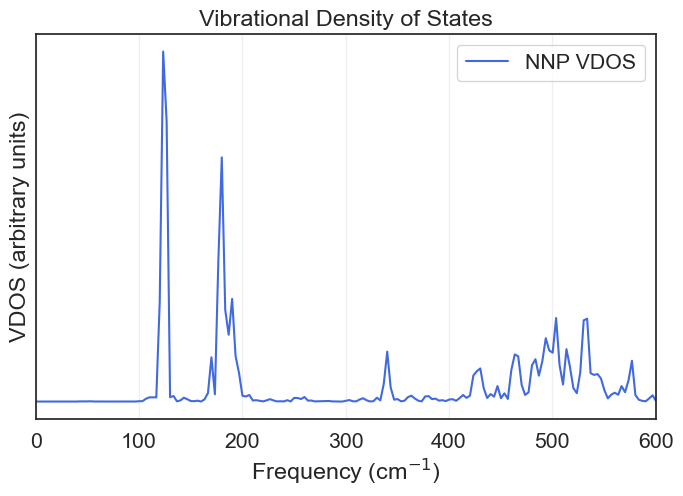

In [ ]:
## VDOS is calculated as the Fourier transform of the Velocity Autocorrelation Function (VACF)

# trajectory_velocities shape: (n_frames, n_atoms, 3)
n_frames = trajectory_velocities.shape[0]
dt_ps = dt # Your timestep in picoseconds (e.g., 0.001)

# 1. Calculate VACF
vacf = np.zeros(n_frames)
# Denominator for normalization: <v(0) . v(0)>
v0_sq = np.sum(trajectory_velocities[0] * trajectory_velocities[0])

# We use the first frame as t=0 for simplicity. 
# For better statistics, you would average over multiple time origins.
for t in range(n_frames):
    dot_product = np.sum(trajectory_velocities[t] * trajectory_velocities[0])
    vacf[t] = dot_product / v0_sq

# 2. Apply a window function (optional but recommended)
# This reduces "leakage" in the Fourier transform caused by the finite length of the simulation
window = np.hanning(n_frames)
vacf_windowed = vacf * window

# 3. Fourier Transform to get VDOS
vdos = np.abs(fft(vacf_windowed))**2

# Get the corresponding frequencies
# dt_ps is in picoseconds, so frequencies will be in THz
frequencies_thz = fftfreq(n_frames, d=dt_ps)

# Convert THz to cm^-1 (common unit for vibrational spectra)
# 1 THz approx = 33.356 cm^-1
frequencies_cm1 = frequencies_thz * 33.35641

# Keep only the positive half of the spectrum
half_n = n_frames // 2
frequencies_cm1 = frequencies_cm1[:half_n]
vdos = vdos[:half_n]

# 4. Plot the result
plt.figure(figsize=(8, 5))
plt.plot(frequencies_cm1, vdos, label='NNP VDOS', color='royalblue')
# Usually we only plot up to ~600 cm^-1 for Silicon
plt.xlim(0, 600) 
plt.xlabel('Frequency (cm$^{-1}$)')
plt.ylabel('VDOS (arbitrary units)')
plt.title('Vibrational Density of States')
plt.yticks([]) # VDOS units are arbitrary, so we often hide the y-ticks
plt.legend()
plt.grid(alpha=0.3)
plt.show()